# Logical CNOT — Lattice Surgery (Rotated Surface Code)

Lattice-surgery CNOT on the **rotated** surface code, using three patches: Control (C), Target (T), Ancilla (A).

Layout (post-fix rotated convention — verified below with Stim `peek_observable_expectation`):
```
  A — T   (XX merge: side-by-side, offset in x)
  |       (ZZ merge: vertical stack, offset in y)
  C
```

The required LS-CNOT sequence — **`ZZ(c,a)` → `XX(a,t)` → final `Z_A` readout** — is the `"ZZ_XX"`.

Five sub-experiments probe all logical input/output basis combinations:

| Sub-experiment | Init C | Init T | Meas C | Meas T |
|---|---|---|---|---|
| ZZ_ZZ | Z | Z | Z | Z |
| ZX_ZX | Z | X | Z | X |
| XZ_XX | X | Z | X | X |
| XZ_ZZ | X | Z | Z | Z |
| XX_XX | X | X | X | X |

Code: **Rotated** Surface Code, d=3, p=1e-3. 

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import stim

from lightstim.protocols.cnot_ls import CNOTLSExperiment
from lightstim.qec_code.surface_code.rotated import (
    RotatedSurfaceCode,
    RotatedSurfaceCodeExtractionBlock,
    RotatedTwoPatchCoupler,
)
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3
rounds = 2   # rounds=2 keeps the detector-slice picture simple; the LER cell uses rounds=d (paper convention)
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

# Protocol variant — controls the ancilla init, which fixes the merge order:
#   "ZZ_XX" — ancilla |+>, ZZ merge (C–A) first, then XX merge (T–A), measure A in Z  <-- required CNOT sequence
#   "XX_ZZ" — ancilla |0>, XX merge (T–A) first, then ZZ merge (C–A), measure A in X
PROTOCOL = "ZZ_XX"

CNOT_SUB_EXPERIMENTS = [
    # (label,  init_C, init_T, meas_C, meas_T)
    ("ZZ_ZZ", "Z", "Z", "Z", "Z"),
    ("ZX_ZX", "Z", "X", "Z", "X"),
    ("XZ_XX", "X", "Z", "X", "X"),
    ("XZ_ZZ", "X", "Z", "Z", "Z"),
    ("XX_XX", "X", "X", "X", "X"),
]


def build_cnot(d, ic, it, mc, mt, *, protocol=PROTOCOL, rounds=rounds, noise=noise_params):
    "Build one rotated LS-CNOT sub-experiment. Returns (circuit, experiment)."
    ancilla_init = "X" if protocol == "ZZ_XX" else "Z"
    ancilla_meas = "Z" if protocol == "ZZ_XX" else "X"   # |+> -> measure Z, |0> -> measure X
    with contextlib.redirect_stdout(io.StringIO()):
        exp = CNOTLSExperiment(
            patch_configs={"c": {"distance": d}, "t": {"distance": d}, "a": {"distance": d}},
            offset_ca=(0, 2 * d + 2),   # Control below Ancilla  -> ZZ(C,A) vertical stack
            offset_ta=(2 * d + 2, 0),   # Target beside Ancilla  -> XX(A,T) side-by-side
            initial_state_dict={"a": ancilla_init, "c": ic, "t": it},
            measure_state_dict={"a": ancilla_meas, "c": mc, "t": mt},
            code_patch_class=RotatedSurfaceCode,
            coupler_class=RotatedTwoPatchCoupler,
            extraction_block_class=RotatedSurfaceCodeExtractionBlock,
            rotate_patches=False,                          # rotated code already aligned (X̄ vertical / Z̄ horizontal)
            rounds=rounds,
            noise_params=noise,
        )
        circ = exp.build()
    return circ, exp

## Build Circuits

Build all 5 sub-experiments and report size + the **final observable count** (`nobs`).

In [3]:
circuits = {}
print(f"PROTOCOL = {PROTOCOL}    (d={d}, rounds={rounds}, p={p})\n")
print(f"{'sub':8} {'qubits':>7} {'detectors':>10} {'observables':>12}")
print("-" * 42)
for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS:
    circ, _ = build_cnot(d, ic, it, mc, mt)
    circuits[sub] = circ
    print(f"{sub:8} {circ.num_qubits:7d} {circ.num_detectors:10d} {circ.num_observables:12d}")

PROTOCOL = ZZ_XX    (d=3, rounds=2, p=0.001)

sub       qubits  detectors  observables
------------------------------------------
ZZ_ZZ         65        152            2
ZX_ZX         65        152            2
XZ_XX         65        152            1
XZ_ZZ         65        152            1
XX_XX         65        152            2


## Detector Slice (ZZ_ZZ sub-experiment)

The two seams (the vertical C–A ZZ merge and the horizontal A–T XX merge) are visible in the noiseless detector slice.

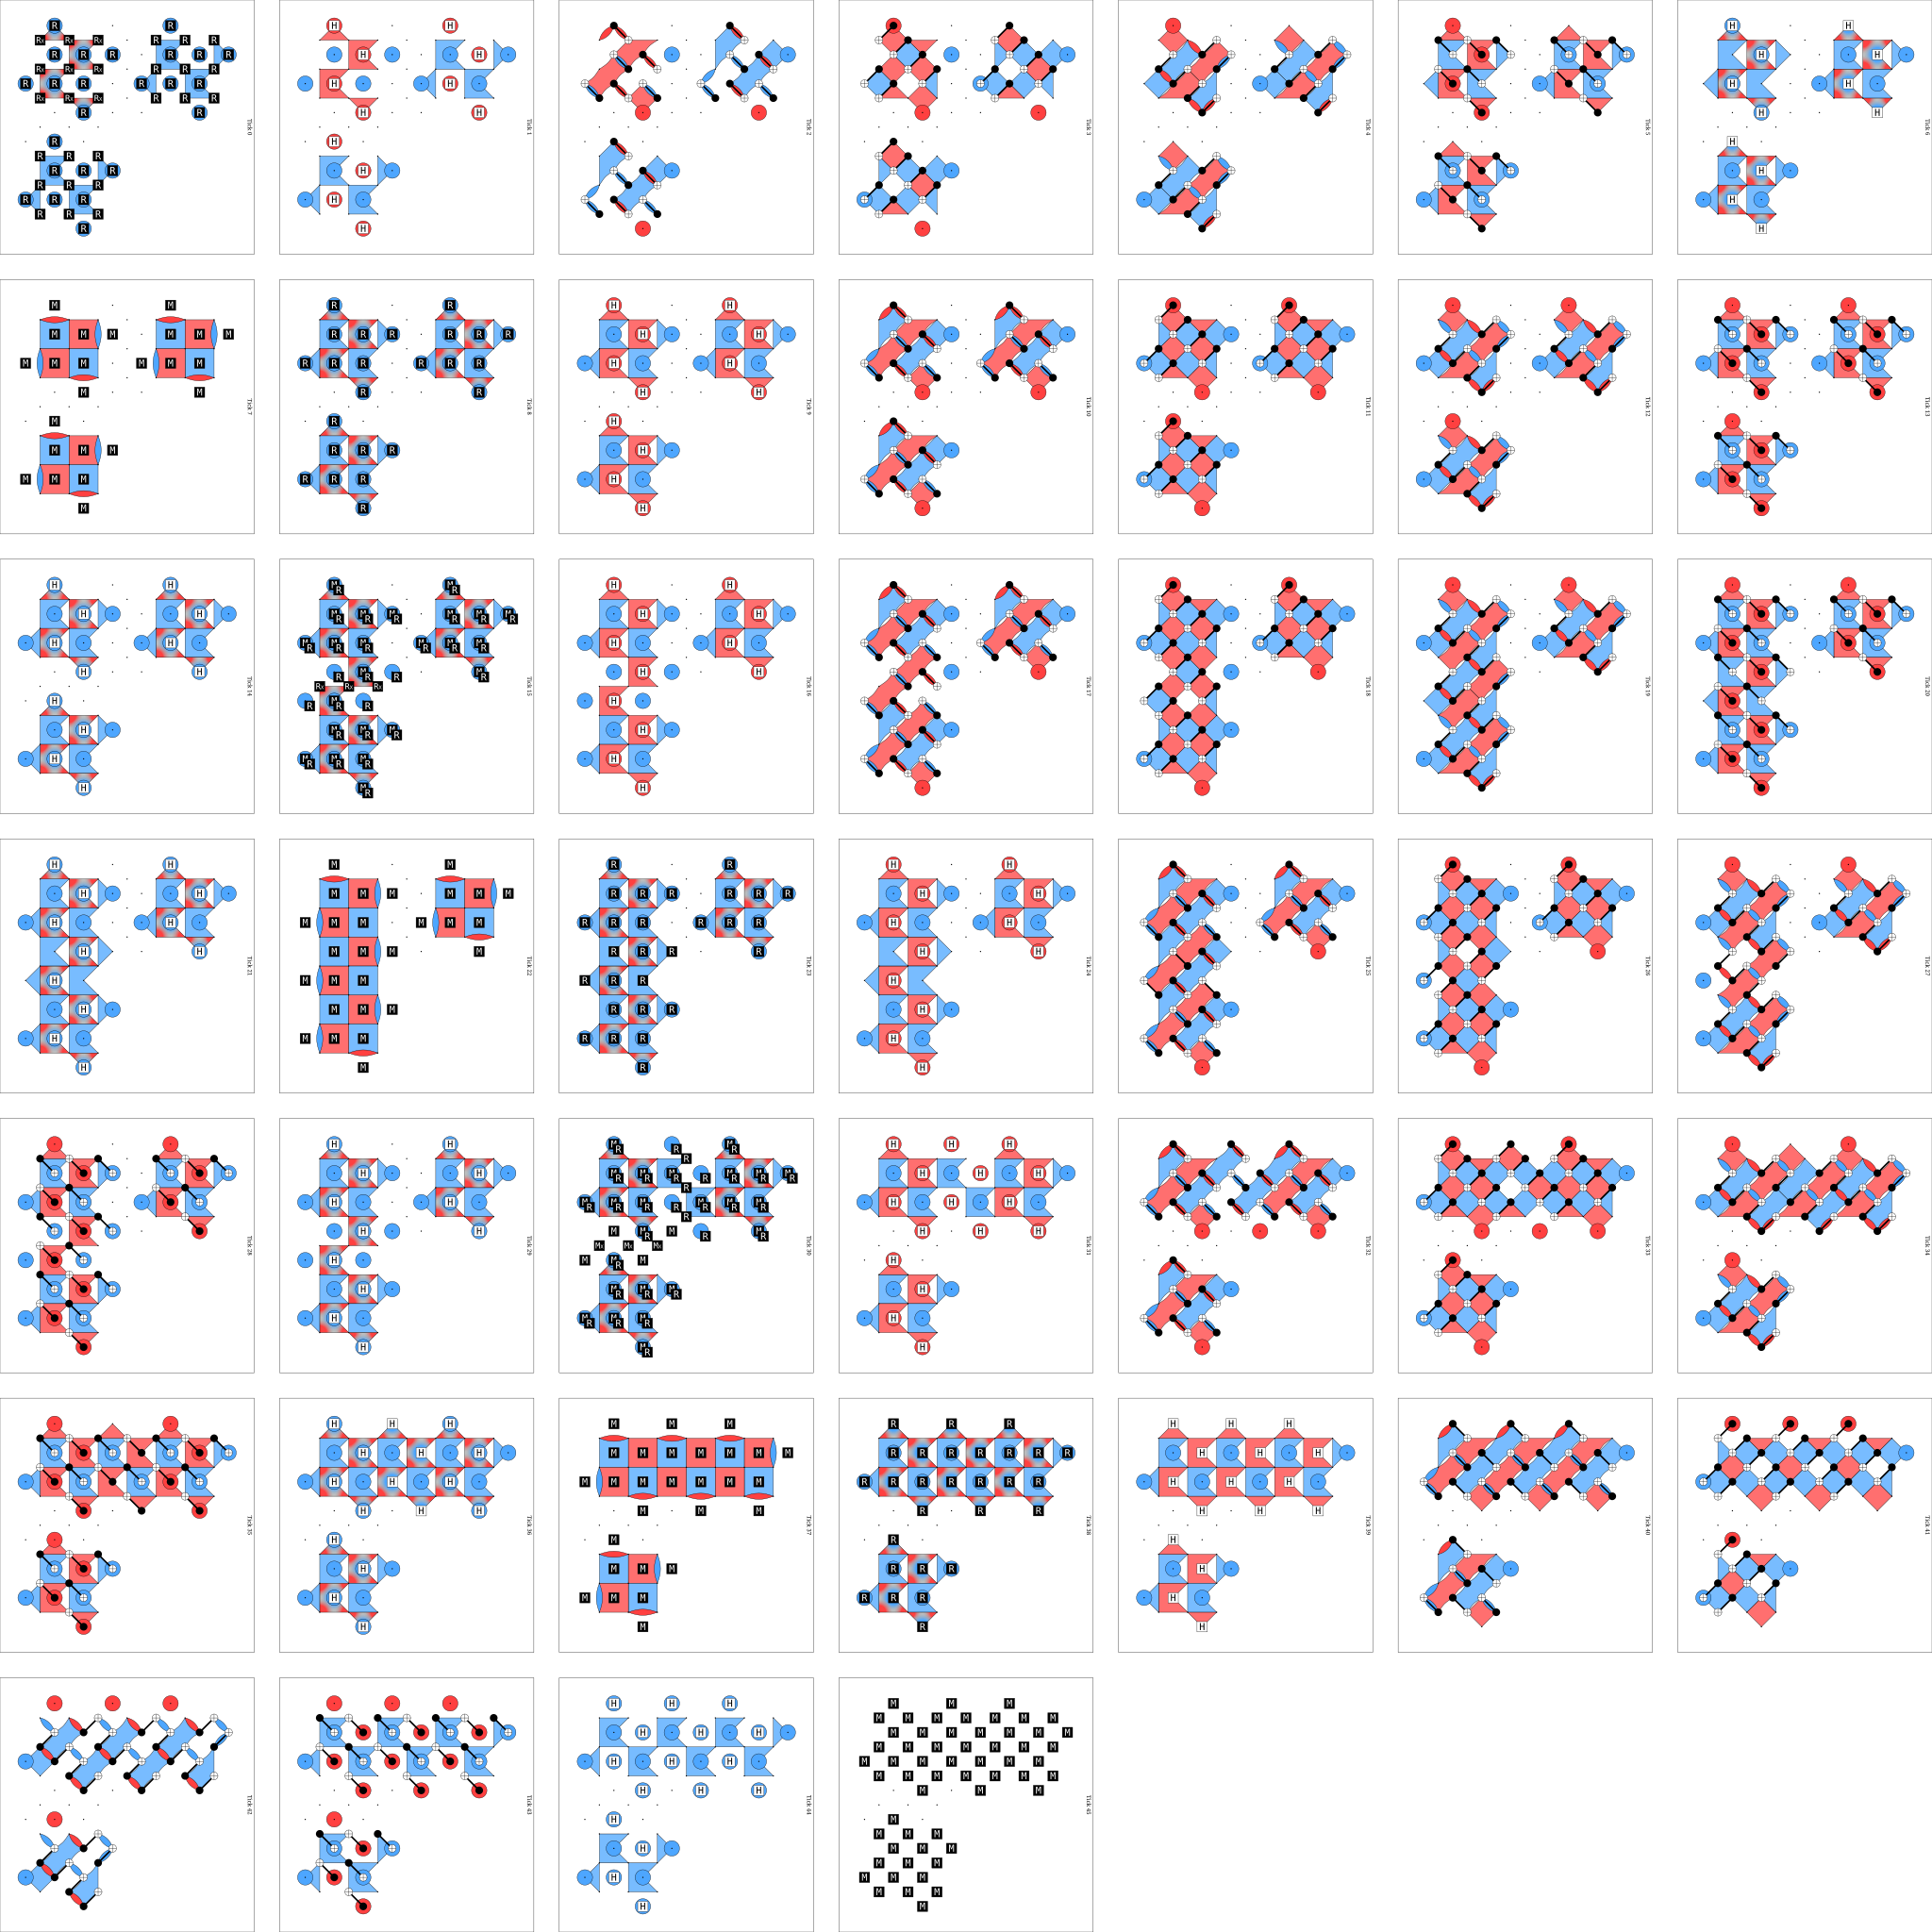

In [4]:
circuits["ZZ_ZZ"].without_noise().diagram("detslice-with-ops-svg")

## Verification 1 — clean build, DEM validity, and observable count vs unrotated

Each sub-experiment must (a) be **noiseless-clean** (no detector/observable fires with noise off), (b) have a **valid decomposed DEM**, and (c) produce the **same number of logical observables** as the unrotated LS-CNOT.

In [5]:
# Reference: the unrotated LS-CNOT observable counts (matched exactly by the rotated build).
UNROTATED_NOBS = {"ZZ_ZZ": 2, "ZX_ZX": 2, "XZ_XX": 1, "XZ_ZZ": 1, "XX_XX": 2}

print(f"{'sub':8} {'clean':>6} {'dem_valid':>10} {'nobs':>5} {'unrot':>6} {'match':>6}")
print("-" * 46)
all_ok = True
for sub, circ in circuits.items():
    sampler = circ.without_noise().compile_detector_sampler()
    det, obs = sampler.sample(shots=500, separate_observables=True)
    clean = (not det.any()) and (not obs.any())
    try:
        circ.detector_error_model(decompose_errors=True)
        dem_valid = True
    except Exception:
        dem_valid = False
    nobs = circ.num_observables
    ref = UNROTATED_NOBS[sub]
    match = (nobs == ref)
    all_ok &= clean and dem_valid and match
    print(f"{sub:8} {str(clean):>6} {str(dem_valid):>10} {nobs:5d} {ref:6d} {str(match):>6}")

print(f"\nAll 5 sub-experiments clean + DEM-valid + nobs matches unrotated: {all_ok}")
assert all_ok

sub       clean  dem_valid  nobs  unrot  match
----------------------------------------------
ZZ_ZZ      True       True     2      2   True
ZX_ZX      True       True     2      2   True
XZ_XX      True       True     1      1   True
XZ_ZZ      True       True     1      1   True
XX_XX      True       True     2      2   True

All 5 sub-experiments clean + DEM-valid + nobs matches unrotated: True


## Verification 2 — LER distance suppression (d=3 vs d=5)

Quick sanity check at `p=1e-3` with `rounds=d` (paper convention). Error correction works iff the larger code suppresses the logical error rate: **LER(d=5) < LER(d=3)**. We report per-sub-experiment LER and the comprehensive weighted average.

In [6]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=200_000,
    max_errors=60,
    num_workers=8,
    print_progress=False,
)

# weights for the comprehensive protocol LER: 1/4·(ZZ_ZZ + ZX_ZX + 1/2·(XZ_XX + XZ_ZZ) + XX_XX)
WEIGHTS = {"ZZ_ZZ": 1 / 4, "ZX_ZX": 1 / 4, "XZ_XX": 1 / 8, "XZ_ZZ": 1 / 8, "XX_XX": 1 / 4}

ler_by_d = {}
for dd in (3, 5):
    print(f"--- d={dd}, rounds={dd}, p={p} ---")
    per_sub = {}
    for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS:
        circ, _ = build_cnot(dd, ic, it, mc, mt, rounds=dd,
                             noise=NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p))
        stats = pipeline.run(circ)
        per_sub[sub] = stats.logical_error_rate
        print(f"  {sub:8}: LER={stats.logical_error_rate:.3e}  ({stats.errors} err / {stats.shots:,} shots)")
    comp = sum(WEIGHTS[s] * per_sub[s] for s in per_sub)
    ler_by_d[dd] = comp
    print(f"  comprehensive LER = {comp:.3e}\n")

print(f"LER(d=3) = {ler_by_d[3]:.3e}")
print(f"LER(d=5) = {ler_by_d[5]:.3e}")

--- d=3, rounds=3, p=0.001 ---


  ZZ_ZZ   : LER=1.554e-02  (1088 err / 70,000 shots)


  ZX_ZX   : LER=9.171e-03  (642 err / 70,000 shots)


  XZ_XX   : LER=1.333e-02  (933 err / 70,000 shots)


  XZ_ZZ   : LER=1.327e-02  (796 err / 60,000 shots)


...

  ZZ_ZZ   : LER=1.536e-03  (169 err / 110,000 shots)


  ZX_ZX   : LER=1.100e-03  (143 err / 130,000 shots)


  XZ_XX   : LER=1.718e-03  (189 err / 110,000 shots)


  XZ_ZZ   : LER=1.255e-03  (138 err / 110,000 shots)


  XX_XX   : LER=2.160e-03  (216 err / 100,000 shots)
  comprehensive LER = 1.571e-03

LER(d=3) = 1.400e-02
LER(d=5) = 1.571e-03


## LER vs Physical Error Rate

Sweep the physical error rate `p ∈ {1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2}` and plot the **mean logical error rate over the 5 sub-experiments**, one curve per code distance (`rounds = d`, paper convention). Below threshold the larger code suppresses errors (LER(d=5) < LER(d=3)); the two curves cross in the threshold region (`p ≈ 5e-3`–`1e-2`).

  d         p   mean LER (over 5 sub-experiments)
------------------------------------------------


  3     1e-03   1.402e-02


  3     2e-03   3.850e-02


  3     3e-03   7.188e-02


  3     5e-03   1.550e-01


...

  7     2e-03   2.705e-03


  7     3e-03   1.411e-02


  7     5e-03   9.292e-02


  7     7e-03   2.615e-01


  7     1e-02   5.102e-01


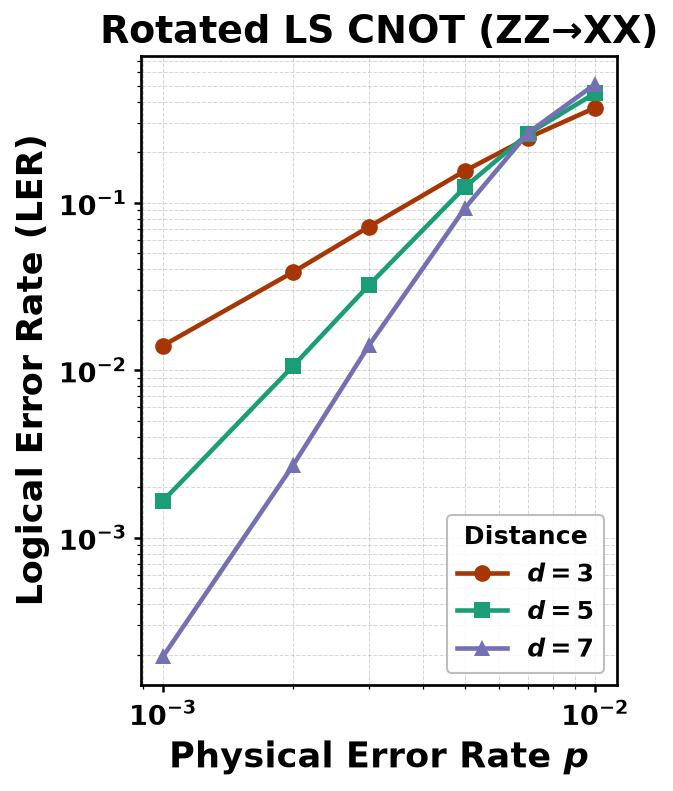

In [3]:
# ── LER vs Physical Error Rate ────────────────────────────────────────────────
# Sweep the physical error rate and plot the mean logical error rate over the 5
# sub-experiments, one curve per code distance (rounds = d, paper convention).
# Below threshold the larger code wins (LER(d=5) < LER(d=3)); the curves cross
# in the threshold region (p ~ 5e-3 to 1e-2).
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from lightstim.plot.styles import apply_paper_style, bold_ticks, PALETTE_DISTANCE
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # silence bold-font warnings

P_SWEEP   = [1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2]
DISTANCES = [3, 5, 7]
MARKERS   = {3: "o", 5: "s", 7: "^"}

sweep_pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=200_000,
    max_errors=60,
    num_workers=8,
    print_progress=False,
)

TITLE = "Rotated LS CNOT (ZZ→XX)"

ler_curves = {dd: [] for dd in DISTANCES}
print(f"{'d':>3} {'p':>9}   mean LER (over 5 sub-experiments)")
print("-" * 48)
for dd in DISTANCES:
    for pp in P_SWEEP:
        noise = NoiseConfig(p_idle=pp, p_1q=pp, p_2q=pp, p_meas=pp, p_reset=pp)
        lers = []
        for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS:
            circ, _ = build_cnot(dd, ic, it, mc, mt, rounds=dd, noise=noise)
            lers.append(sweep_pipeline.run(circ).logical_error_rate)
        mean_ler = float(np.mean(lers))
        ler_curves[dd].append(mean_ler)
        print(f"{dd:>3} {pp:>9.0e}   {mean_ler:.3e}")

apply_paper_style()
fig, ax = plt.subplots(figsize=(4.5, 5.5))
proxies = []
for dd in DISTANCES:
    color  = PALETTE_DISTANCE.get(dd, "gray")
    marker = MARKERS.get(dd, "o")
    _y = np.array(ler_curves[dd], dtype=float)
    _y[_y <= 0] = np.nan  # drop zero-error points (e.g. d=7 low-p) from the log plot
    ax.loglog(P_SWEEP, _y, marker=marker, color=color,
              linestyle="-", markeredgecolor="none")
    proxies.append(mlines.Line2D([], [], color=color, ls="-", marker=marker,
                                 markersize=8, markeredgecolor="none", label=f"$d = {dd}$"))

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate (LER)")
ax.set_title(TITLE)
ax.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.5)
bold_ticks(ax)
leg = ax.legend(handles=proxies, title="Distance", loc="lower right",
                frameon=True, framealpha=0.85)
leg.get_title().set_fontweight("bold")
fig.tight_layout()
plt.show()
